# AFM tip + Si/SiGe FEniCSx run vs. Leah's reference VTK -- cross-sections

This notebook is a companion to `afm_tip_vs_leah_vtk_comparison.ipynb` (not
edited here to avoid clobbering parallel work). It reuses the same
`poisson.vtk_xdmf_compare` module and adds **depth cross-sections**
(x=0 and y=0 planes, full z-depth) in addition to the usual top-view
(xy, fixed-z) slices, since this device is closer to rotationally
symmetric about the vertical (z) axis and the AFM tip sits at x=0,y=0 --
a cross-section through the origin plane is the view that actually shows
how the tip's potential penetrates down through the Si/SiGe stack
(interfaces at z = 2, 30, 40, 43, 53 nm, then a thick buffer down to the
grounded bottom at z=2053 nm).

In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.home() / "Desktop" / "poisson_solver"
sys.path.insert(0, str(PROJECT_ROOT / "src"))

from poisson.vtk_xdmf_compare import (
    XdmfCase,
    read_vtk_reference,
    read_xdmf_case,
    interpolate_case_onto_ref,
    plot_slice_pair,
    plot_cross_section,
)

%matplotlib inline

## Configuration

`RUN_NUMBER` picks which `notebooks/afm_vs_leah_compare/runN/` directory to
compare against Leah's VTK reference (`basePotential3d(1).vtk`). Using
run1, which exists on disk alongside run3.

In [2]:
RUN_NUMBER = 3

vtk_path = Path.home() / "Downloads" / "basePotential3d(1).vtk"
run_dir = PROJECT_ROOT / "notebooks" / "afm_vs_leah_compare" / f"run{RUN_NUMBER}"
xdmf_path = run_dir / "sige_afm_tip.xdmf"
out_dir = run_dir / "vs_leah_vtk"
cross_dir = out_dir / "cross_sections"
cross_dir.mkdir(parents=True, exist_ok=True)

label = f"run{RUN_NUMBER} (phi_V)"
print(f"vtk_path = {vtk_path}")
print(f"xdmf_path = {xdmf_path}")
print(f"cross_dir = {cross_dir}")

vtk_path = /Users/angelramirez/Downloads/basePotential3d(1).vtk
xdmf_path = /Users/angelramirez/Desktop/poisson_solver/notebooks/afm_vs_leah_compare/run3/sige_afm_tip.xdmf
cross_dir = /Users/angelramirez/Desktop/poisson_solver/notebooks/afm_vs_leah_compare/run3/vs_leah_vtk/cross_sections


## Read reference + case, interpolate once

`interpolate_case_onto_ref` linearly interpolates the FEM (`phi_V`) field
onto the VTK reference's own grid points (with nearest-neighbor fallback
outside the FEM mesh's convex hull). All the slices/cross-sections below
just mask this single combined result by coordinate -- no repeated
interpolation.

In [3]:
ref = read_vtk_reference(vtk_path)
print(f"VTK reference: field='{ref.name}', {len(ref.points)} points")

case = XdmfCase(label, xdmf_path, field="phi_V", scale=1.0)
case_data = read_xdmf_case(case)
print(f"XDMF case: field='{case_data.name}', {len(case_data.points)} points")

result = interpolate_case_onto_ref(ref, case_data, label)
print(f"Interpolated result: {len(result.points)} points, "
      f"nearest_fallback_frac={result.nearest_fallback_frac:.1%}")

VTK reference: field='basePotential', 636291 points
XDMF case: field='phi_V', 89527 points


Interpolated result: 636291 points, nearest_fallback_frac=0.0%


## (a) Top-view (xy) slices at two example depths

`z=0` is the top surface (where the AFM tip contacts / hovers above the
device); `z=35 nm` sits inside the "top well" depth range (between the
2/30/40/43/53 nm layer interfaces) that matters physically for this
device. These reuse the existing `plot_slice_pair` unchanged.

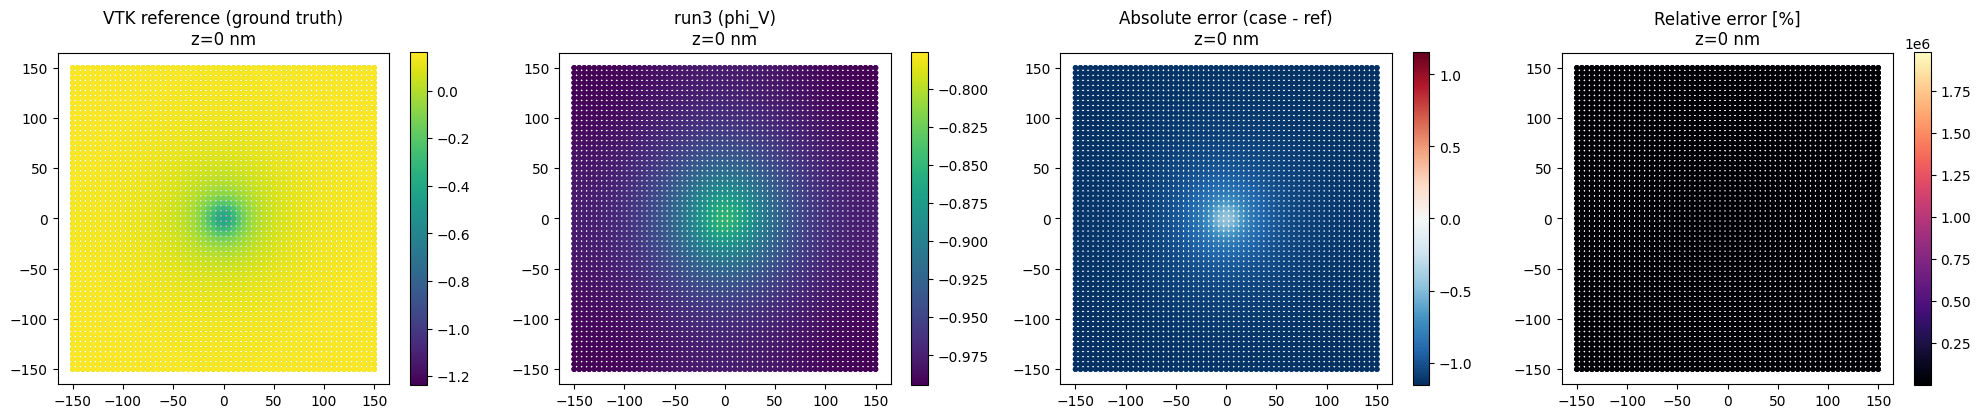

Saved: /Users/angelramirez/Desktop/poisson_solver/notebooks/afm_vs_leah_compare/run3/vs_leah_vtk/cross_sections/xy_slice_z0.png


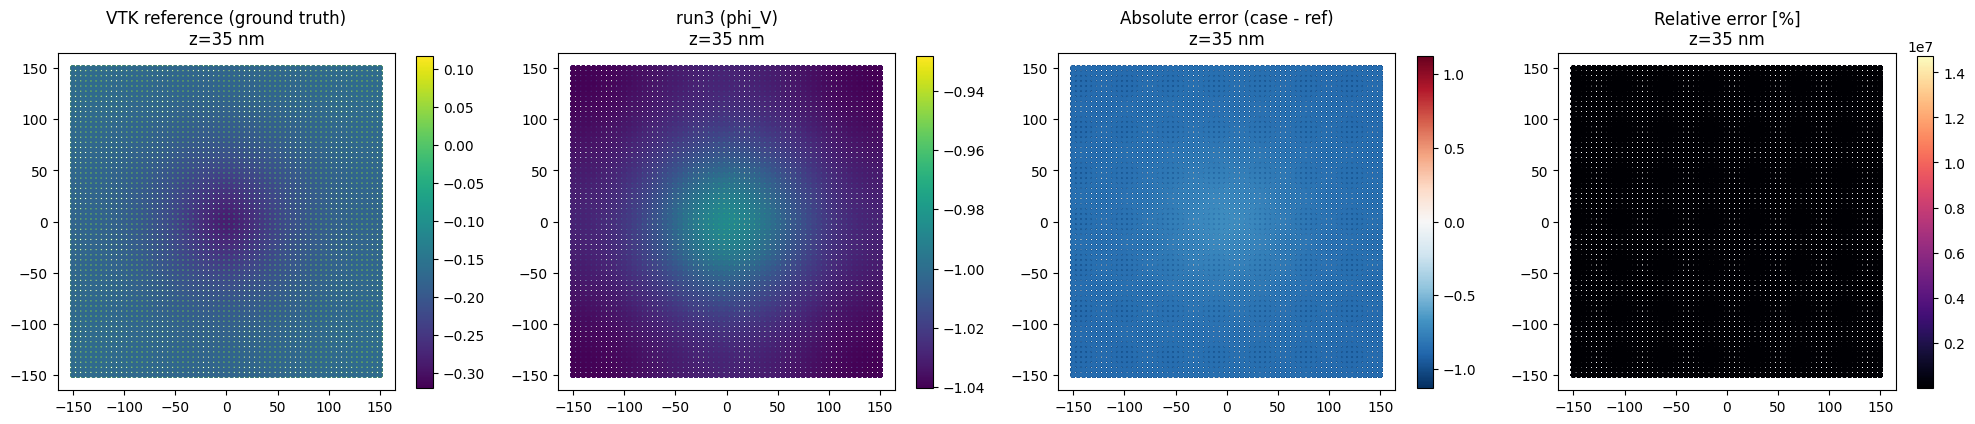

Saved: /Users/angelramirez/Desktop/poisson_solver/notebooks/afm_vs_leah_compare/run3/vs_leah_vtk/cross_sections/xy_slice_z35.png


In [4]:
for z in (0.0, 35.0):
    save_path = cross_dir / f"xy_slice_z{z:g}.png"
    plot_slice_pair(result, z, label, units=" nm", save_path=save_path, show=True)
    print(f"Saved: {save_path}")

## (b) xz cross-section at y=0 (full z-depth)

Slices the device at y=0, plotting (x, z) with z as the vertical axis,
**increasing downward** (z is physical depth: the AFM tip is above,
the grounded buffer/bottom is below). This shows how the tip's potential
penetrates straight down through the Si/SiGe stack along the x-direction.

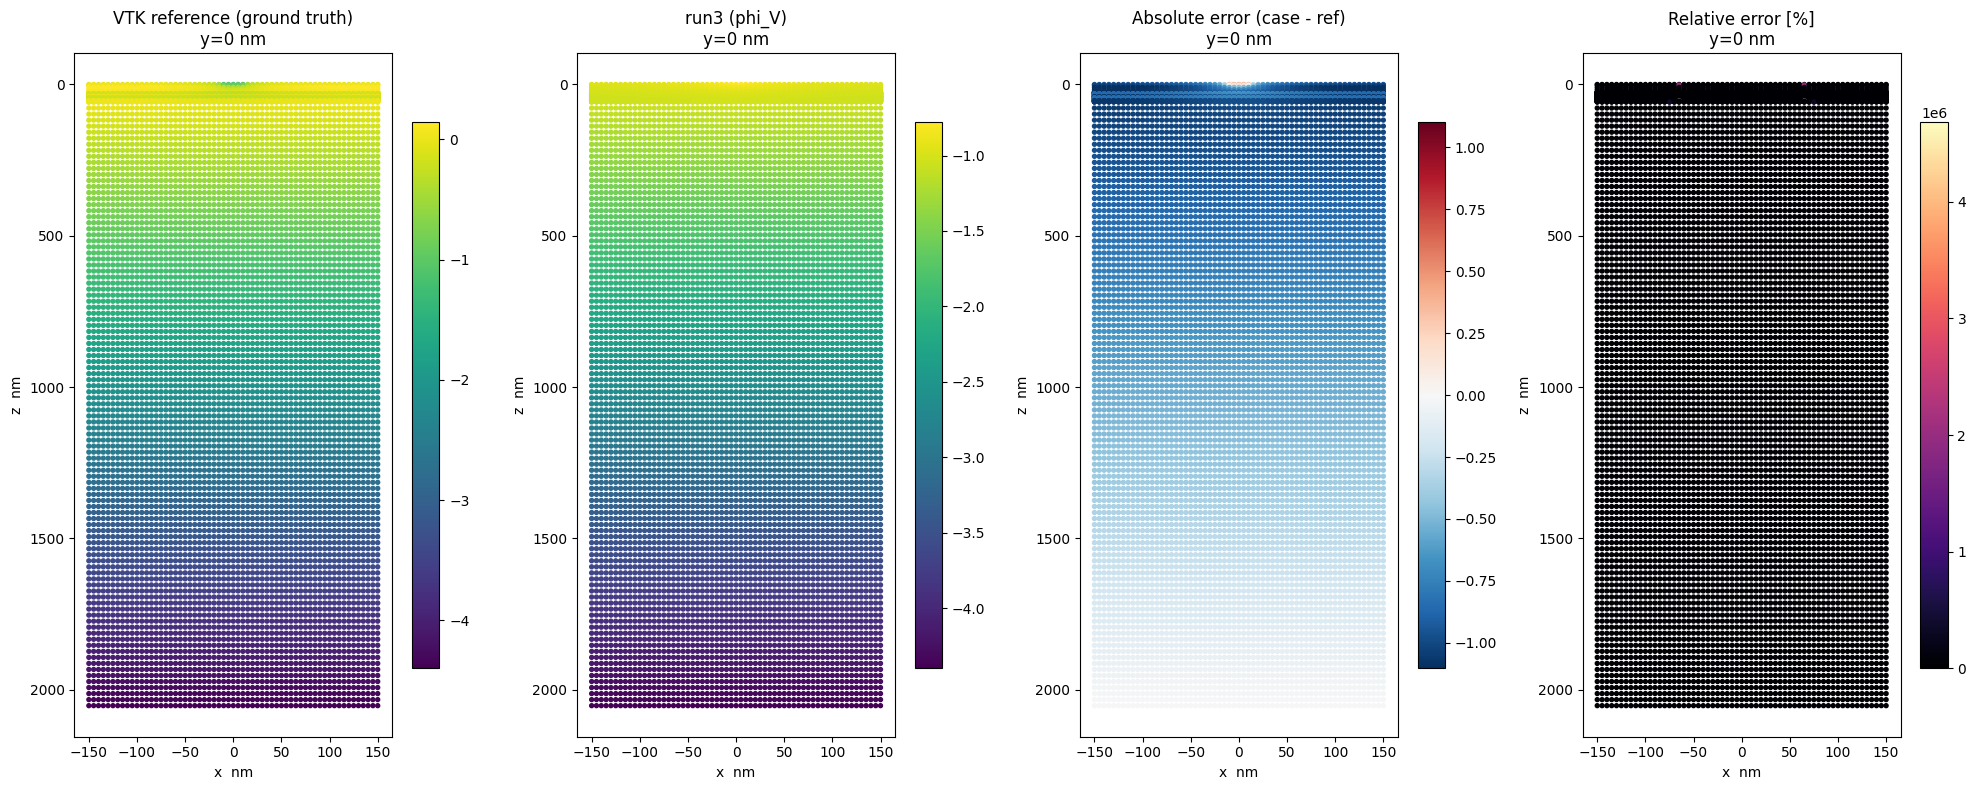

Saved: /Users/angelramirez/Desktop/poisson_solver/notebooks/afm_vs_leah_compare/run3/vs_leah_vtk/cross_sections/xz_cross_section_y0.png


In [5]:
save_path = cross_dir / "xz_cross_section_y0.png"
plot_cross_section(result, axis="y", coord_value=0.0, label=label, units=" nm",
                    save_path=save_path, show=True)
print(f"Saved: {save_path}")

## (c) yz cross-section at x=0 (full z-depth)

Same idea, sliced at x=0 instead, plotting (y, z) with z increasing
downward. Together with (b) these two orthogonal cross-sections through
the origin give a full picture of how the potential decays with depth
beneath the tip.

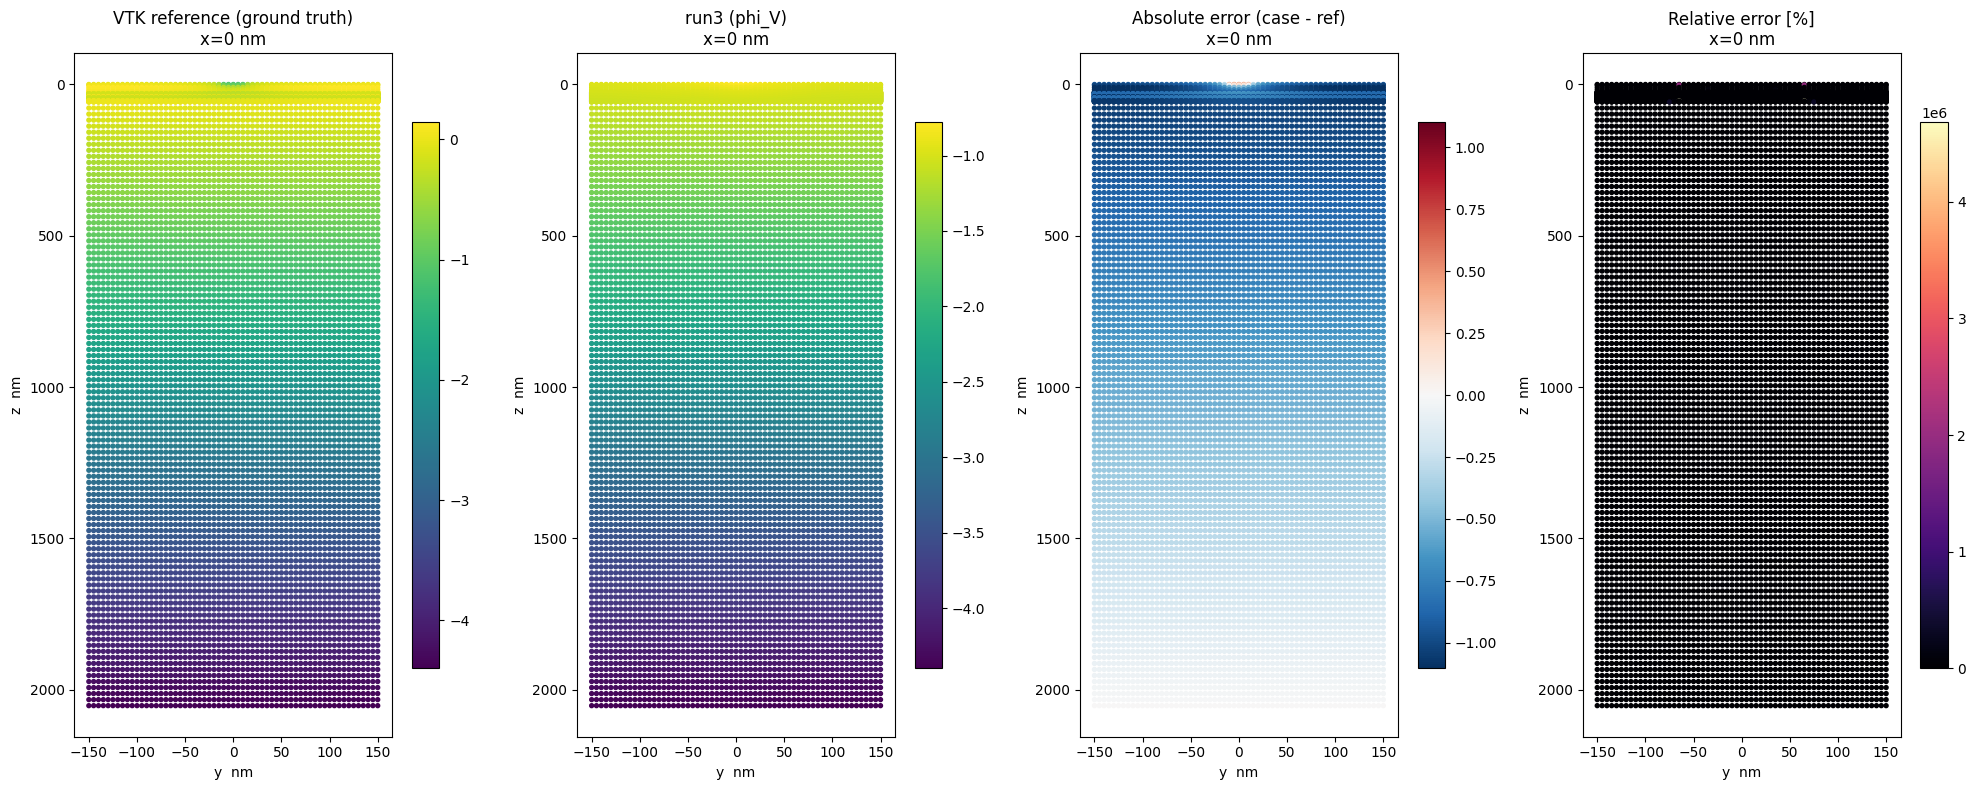

Saved: /Users/angelramirez/Desktop/poisson_solver/notebooks/afm_vs_leah_compare/run3/vs_leah_vtk/cross_sections/yz_cross_section_x0.png


In [6]:
save_path = cross_dir / "yz_cross_section_x0.png"
plot_cross_section(result, axis="x", coord_value=0.0, label=label, units=" nm",
                    save_path=save_path, show=True)
print(f"Saved: {save_path}")

## Summary

All figures above are saved as PNGs in `run_dir / "vs_leah_vtk" / "cross_sections"`:

- `xy_slice_z0.png`, `xy_slice_z35.png` -- top-view slices at two depths
- `xz_cross_section_y0.png` -- full-depth cross-section at y=0
- `yz_cross_section_x0.png` -- full-depth cross-section at x=0

In [7]:
import os
print("Files in cross_dir:")
for f in sorted(os.listdir(cross_dir)):
    print(" ", f)

Files in cross_dir:
  xy_slice_z0.png
  xy_slice_z35.png
  xz_cross_section_y0.png
  yz_cross_section_x0.png


## (d) Full 3D point-by-point comparison

Everything above only looked at 2D slices/cross-sections through the origin.
This section builds a genuine 3D comparison using every point in the VTK
reference's own grid (reusing the already-computed `result` from the
"Read reference + case, interpolate once" cell above -- no re-interpolation).

For each of the ~636k points we compute:

- `signed_error_V = phi_V (FEM) - basePotential (VTK)`
- `abs_error_V = |signed_error_V|`
- `rel_error_pct_masked`: `100 * abs_error_V / |basePotential|`, but set to
  `NaN` wherever `|basePotential| <= 0.044 V` (1% of the VTK's own peak
  |phi|, ~4.4 V) -- this repo's established convention for avoiding
  meaningless blown-up percentages where the VTK field crosses/approaches
  zero.

**Interpretation caveat:** it is currently unresolved whether this VTK
reference (`basePotential3d(1).vtk`) even includes an AFM-tip contribution
at all (see `notebooks/afm_vs_leah_compare/run3/diagnostics/physical_case_audit.md`,
still open). The plots and numbers below are purely descriptive -- they
show *where* the FEM and VTK potentials agree/disagree, not *why*. No
conclusion about tip voltage or geometry correctness is drawn here.

In [8]:
import numpy as np
import pyvista as pv

points = result.points
ref_v = result.ref_values
case_v = result.case_values
signed_err = case_v - ref_v
abs_err = np.abs(signed_err)

REL_ERR_FLOOR_V = 0.044  # 1% of VTK's own peak |phi| (~4.4 V), established repo convention
rel_err_pct = 100.0 * abs_err / np.abs(ref_v)
rel_err_pct[np.abs(ref_v) <= REL_ERR_FLOOR_V] = np.nan

rel_err_pct_unmasked = 100.0 * abs_err / np.maximum(np.abs(ref_v), 1e-12)

n_total = len(points)
n_masked_out = int(np.isnan(rel_err_pct).sum())
print(f"Total points: {n_total:,}")
print(f"Signed error (FEM - VTK): mean={signed_err.mean():.4g} V, std={signed_err.std():.4g} V, "
      f"min={signed_err.min():.4g} V, max={signed_err.max():.4g} V")
print(f"Absolute error: mean={abs_err.mean():.4g} V, median={np.median(abs_err):.4g} V, "
      f"max={abs_err.max():.4g} V")
print(f"Masked relative error (|VTK|>{REL_ERR_FLOOR_V} V): "
      f"{n_total - n_masked_out:,} / {n_total:,} points retained "
      f"({(n_total - n_masked_out) / n_total:.1%}); "
      f"mean={np.nanmean(rel_err_pct):.4g}%, median={np.nanmedian(rel_err_pct):.4g}%, "
      f"max={np.nanmax(rel_err_pct):.4g}%")
print(f"[UNRELIABLE near zero] Unmasked relative error: "
      f"mean={rel_err_pct_unmasked.mean():.4g}%, max={rel_err_pct_unmasked.max():.4g}% "
      f"(inflated by points where VTK phi ~ 0 -- do not trust this number)")

cloud = pv.PolyData(points)
cloud["basePotential_ref_V"] = ref_v
cloud["phi_V_fem"] = case_v
cloud["signed_error_V"] = signed_err
cloud["abs_error_V"] = abs_err
cloud["rel_error_pct_masked"] = rel_err_pct

comparison_dir = run_dir / "vs_leah_vtk" / "3d_comparison"
comparison_dir.mkdir(parents=True, exist_ok=True)

npz_path = comparison_dir / "pointwise_comparison_arrays.npz"
np.savez(
    npz_path,
    x=points[:, 0], y=points[:, 1], z=points[:, 2],
    ref_V=ref_v, case_V=case_v,
    signed_err_V=signed_err, abs_err_V=abs_err, rel_err_pct_masked=rel_err_pct,
)
print(f"Saved FULL-resolution ({n_total:,} points x 8 columns) arrays to: {npz_path}")

Total points: 636,291
Signed error (FEM - VTK): mean=-0.6945 V, std=0.3188 V, min=-1.154 V, max=0.459 V
Absolute error: mean=0.6946 V, median=0.8153 V, max=1.154 V
Masked relative error (|VTK|>0.044 V): 583,439 / 636,291 points retained (91.7%); mean=333%, median=86.13%, max=2399%
[UNRELIABLE near zero] Unmasked relative error: mean=1722%, max=1.475e+07% (inflated by points where VTK phi ~ 0 -- do not trust this number)
Saved FULL-resolution (636,291 points x 8 columns) arrays to: /Users/angelramirez/Desktop/poisson_solver/notebooks/afm_vs_leah_compare/run3/vs_leah_vtk/3d_comparison/pointwise_comparison_arrays.npz


### Rendering setup: subsampling and camera views

The device is extremely elongated: x,y span only -150..150 nm while z spans
0..2053 nm (a thick grounded buffer beneath the physically interesting
layers/tip/well region). Two sets of renders are produced:

1. **Full extent, true proportions** -- all z from 0 to 2053 nm, plotted in
   real (unstretched) coordinates, so the reader sees how thin/tall the
   actual device geometry is. Rendered from a subsampled point cloud
   (subsampling is for the PNG only -- see next cell for the exact
   fraction kept; the full-resolution arrays above and the saved `.npz`
   are unaffected).
2. **Zoomed to device region** -- restricted to `z <= 100 nm`, where the
   AFM tip, the Si/SiGe layer stack (interfaces at 2/30/40/43/53 nm), and
   the top well actually live. Since this is already a much smaller point
   count, it is rendered at **full resolution** (no subsampling).

For each of the 5 fields (VTK reference, FEM, signed error, absolute
error, masked relative error) two camera angles are saved per PNG set:

- **iso**: an isometric 3/4 view of the whole cloud.
- **topdown**: looking straight down the z-axis at the xy plane
  (`pyvista`'s `view_xy()`), so lateral (x,y) concentration of error is
  visible independent of depth.

Colormaps: `viridis` for the raw potentials, zero-centered `RdBu_r` for
signed error, `magma` for absolute/relative error magnitude. Color limits
are computed from the 1st/99th percentiles of the FULL-resolution data (not
the render subsample) so outlier points don't wash out the color scale.

In [9]:
FIELD_NAMES = [
    "basePotential_ref_V", "phi_V_fem", "signed_error_V", "abs_error_V", "rel_error_pct_masked",
]

# --- Full-extent render subsample (PNG rendering only; numerics above stay full-res) ---
RENDER_STRIDE = 4
render_idx = np.arange(0, n_total, RENDER_STRIDE)
cloud_render = pv.PolyData(points[render_idx])
for name in FIELD_NAMES:
    cloud_render[name] = cloud[name][render_idx]
print(f"Full-extent render subsample: {len(render_idx):,} / {n_total:,} points "
      f"({len(render_idx) / n_total:.1%}), every {RENDER_STRIDE}th point by flat index.")

# --- Device-region crop (z <= 100 nm), rendered at FULL resolution ---
DEVICE_Z_MAX = 100.0
device_idx = np.where(points[:, 2] <= DEVICE_Z_MAX)[0]
cloud_device = pv.PolyData(points[device_idx])
for name in FIELD_NAMES:
    cloud_device[name] = cloud[name][device_idx]
print(f"Device-region crop (z <= {DEVICE_Z_MAX:g} nm): {len(device_idx):,} / {n_total:,} points "
      f"({len(device_idx) / n_total:.1%}) -- rendered at FULL resolution, no subsampling.")


def robust_clim(values, signed=False, pct=99):
    finite = values[np.isfinite(values)]
    if finite.size == 0:
        return (0.0, 1.0)
    if signed:
        vmax = np.percentile(np.abs(finite), pct)
        vmax = vmax if vmax > 0 else 1.0
        return (-vmax, vmax)
    lo, hi = np.percentile(finite, [100 - pct, pct])
    if lo == hi:
        hi = lo + 1.0
    return (float(lo), float(hi))


def render_field(cloud_obj, field, cmap, clim, units_label, title, out_prefix, point_size=3.0):
    """Render `field` from an isometric and a top-down (looking down +z at the xy
    plane) camera angle, each saved as its own PNG with a labeled scalar bar."""
    saved = []
    for view_name in ("iso", "topdown"):
        pl = pv.Plotter(off_screen=True, window_size=(1000, 800))
        pl.set_background("white")
        pl.add_mesh(
            cloud_obj,
            scalars=field,
            cmap=cmap,
            clim=clim,
            point_size=point_size,
            render_points_as_spheres=False,
            scalar_bar_args={"title": f"{title} [{units_label}]", "color": "black"},
        )
        pl.add_text(f"{title}\n{view_name} view", font_size=10, color="black")
        if view_name == "topdown":
            pl.view_xy()
        else:
            pl.view_isometric()
        save_path = comparison_dir / f"{out_prefix}_{view_name}.png"
        pl.screenshot(str(save_path))
        pl.close()
        saved.append(save_path)
        print(f"Saved: {save_path}")
    return saved


# Color limits from FULL-resolution numeric arrays (not the render subsample).
ref_clim = robust_clim(ref_v)
case_clim = robust_clim(case_v)
signed_clim = robust_clim(signed_err, signed=True)
abs_clim = (0.0, robust_clim(abs_err)[1])
rel_clim = (0.0, robust_clim(rel_err_pct)[1])
print("Full-extent color limits:", ref_clim, case_clim, signed_clim, abs_clim, rel_clim)

Full-extent render subsample: 159,073 / 636,291 points (25.0%), every 4th point by flat index.
Device-region crop (z <= 100 nm): 271,633 / 636,291 points (42.7%) -- rendered at FULL resolution, no subsampling.
Full-extent color limits: (-4.355884075164795, 0.11536533385515213) (-4.366472627422598, -0.9544856656135363) (np.float64(-1.1233638322130934), np.float64(1.1233638322130934)) (0.0, 1.1233638322130934) (0.0, 1950.7267162053906)


### (d.1) Full-extent renders (true proportions, z = 0..2053 nm)

Ten PNGs (5 fields x 2 camera angles), all using the subsampled render
cloud so the true, extremely elongated aspect ratio of the domain is
visible.

In [10]:
render_field(cloud_render, "basePotential_ref_V", "viridis", ref_clim, "V",
             "VTK reference potential (basePotential)", "full_extent_ref_potential")
render_field(cloud_render, "phi_V_fem", "viridis", case_clim, "V",
             "FEM potential (phi_V, interpolated onto VTK grid)", "full_extent_fem_potential")
render_field(cloud_render, "signed_error_V", "RdBu_r", signed_clim, "V",
             "Signed error (FEM - VTK)", "full_extent_signed_error")
render_field(cloud_render, "abs_error_V", "magma", abs_clim, "V",
             "Absolute error |FEM - VTK|", "full_extent_abs_error")
render_field(cloud_render, "rel_error_pct_masked", "magma", rel_clim, "%",
             "Masked relative error (|VTK|>0.044V)", "full_extent_rel_error_masked")
print("Full-extent renders done.")

Saved: /Users/angelramirez/Desktop/poisson_solver/notebooks/afm_vs_leah_compare/run3/vs_leah_vtk/3d_comparison/full_extent_ref_potential_iso.png
Saved: /Users/angelramirez/Desktop/poisson_solver/notebooks/afm_vs_leah_compare/run3/vs_leah_vtk/3d_comparison/full_extent_ref_potential_topdown.png
Saved: /Users/angelramirez/Desktop/poisson_solver/notebooks/afm_vs_leah_compare/run3/vs_leah_vtk/3d_comparison/full_extent_fem_potential_iso.png


Saved: /Users/angelramirez/Desktop/poisson_solver/notebooks/afm_vs_leah_compare/run3/vs_leah_vtk/3d_comparison/full_extent_fem_potential_topdown.png
Saved: /Users/angelramirez/Desktop/poisson_solver/notebooks/afm_vs_leah_compare/run3/vs_leah_vtk/3d_comparison/full_extent_signed_error_iso.png
Saved: /Users/angelramirez/Desktop/poisson_solver/notebooks/afm_vs_leah_compare/run3/vs_leah_vtk/3d_comparison/full_extent_signed_error_topdown.png


Saved: /Users/angelramirez/Desktop/poisson_solver/notebooks/afm_vs_leah_compare/run3/vs_leah_vtk/3d_comparison/full_extent_abs_error_iso.png


Saved: /Users/angelramirez/Desktop/poisson_solver/notebooks/afm_vs_leah_compare/run3/vs_leah_vtk/3d_comparison/full_extent_abs_error_topdown.png
Saved: /Users/angelramirez/Desktop/poisson_solver/notebooks/afm_vs_leah_compare/run3/vs_leah_vtk/3d_comparison/full_extent_rel_error_masked_iso.png


Saved: /Users/angelramirez/Desktop/poisson_solver/notebooks/afm_vs_leah_compare/run3/vs_leah_vtk/3d_comparison/full_extent_rel_error_masked_topdown.png
Full-extent renders done.


### (d.2) Zoomed-to-device-region renders (z = 0..100 nm, full resolution)

Same 5 fields x 2 camera angles, but cropped to `z <= 100 nm` (tip / layer
stack / top well) and rendered at full point resolution within that crop.
Color limits are recomputed from just this region's full-resolution data
so the smaller dynamic range of the device region isn't washed out by the
much larger range further down in the grounded buffer.

In [11]:
d_ref = cloud_device["basePotential_ref_V"]
d_case = cloud_device["phi_V_fem"]
d_signed = cloud_device["signed_error_V"]
d_abs = cloud_device["abs_error_V"]
d_rel = cloud_device["rel_error_pct_masked"]

device_ref_clim = robust_clim(d_ref)
device_case_clim = robust_clim(d_case)
device_signed_clim = robust_clim(d_signed, signed=True)
device_abs_clim = (0.0, robust_clim(d_abs)[1])
device_rel_clim = (0.0, robust_clim(d_rel)[1])
print("Device-region color limits:", device_ref_clim, device_case_clim,
      device_signed_clim, device_abs_clim, device_rel_clim)

render_field(cloud_device, "basePotential_ref_V", "viridis", device_ref_clim, "V",
             "VTK reference potential (basePotential) -- device region",
             "device_zoom_ref_potential", point_size=4.0)
render_field(cloud_device, "phi_V_fem", "viridis", device_case_clim, "V",
             "FEM potential (phi_V) -- device region",
             "device_zoom_fem_potential", point_size=4.0)
render_field(cloud_device, "signed_error_V", "RdBu_r", device_signed_clim, "V",
             "Signed error (FEM - VTK) -- device region",
             "device_zoom_signed_error", point_size=4.0)
render_field(cloud_device, "abs_error_V", "magma", device_abs_clim, "V",
             "Absolute error |FEM - VTK| -- device region",
             "device_zoom_abs_error", point_size=4.0)
render_field(cloud_device, "rel_error_pct_masked", "magma", device_rel_clim, "%",
             "Masked relative error (|VTK|>0.044V) -- device region",
             "device_zoom_rel_error_masked", point_size=4.0)
print("Device-zoom renders done.")

Device-region color limits: (-0.26722007989883423, 0.13670995831489563) (-1.1123506455573837, -0.9367340894400732) (np.float64(-1.1289596450063948), np.float64(1.1289596450063948)) (0.0, 1.1289596450063948) (0.0, 2124.4535240888085)
Saved: /Users/angelramirez/Desktop/poisson_solver/notebooks/afm_vs_leah_compare/run3/vs_leah_vtk/3d_comparison/device_zoom_ref_potential_iso.png


Saved: /Users/angelramirez/Desktop/poisson_solver/notebooks/afm_vs_leah_compare/run3/vs_leah_vtk/3d_comparison/device_zoom_ref_potential_topdown.png
Saved: /Users/angelramirez/Desktop/poisson_solver/notebooks/afm_vs_leah_compare/run3/vs_leah_vtk/3d_comparison/device_zoom_fem_potential_iso.png


Saved: /Users/angelramirez/Desktop/poisson_solver/notebooks/afm_vs_leah_compare/run3/vs_leah_vtk/3d_comparison/device_zoom_fem_potential_topdown.png
Saved: /Users/angelramirez/Desktop/poisson_solver/notebooks/afm_vs_leah_compare/run3/vs_leah_vtk/3d_comparison/device_zoom_signed_error_iso.png


Saved: /Users/angelramirez/Desktop/poisson_solver/notebooks/afm_vs_leah_compare/run3/vs_leah_vtk/3d_comparison/device_zoom_signed_error_topdown.png
Saved: /Users/angelramirez/Desktop/poisson_solver/notebooks/afm_vs_leah_compare/run3/vs_leah_vtk/3d_comparison/device_zoom_abs_error_iso.png


Saved: /Users/angelramirez/Desktop/poisson_solver/notebooks/afm_vs_leah_compare/run3/vs_leah_vtk/3d_comparison/device_zoom_abs_error_topdown.png
Saved: /Users/angelramirez/Desktop/poisson_solver/notebooks/afm_vs_leah_compare/run3/vs_leah_vtk/3d_comparison/device_zoom_rel_error_masked_iso.png


Saved: /Users/angelramirez/Desktop/poisson_solver/notebooks/afm_vs_leah_compare/run3/vs_leah_vtk/3d_comparison/device_zoom_rel_error_masked_topdown.png
Device-zoom renders done.


In [12]:
## Spatial concentration of error (numeric, full resolution) -- purely descriptive.
top_frac = 0.01
n_top = max(1, int(round(top_frac * n_total)))
top_idx = np.argsort(abs_err)[::-1][:n_top]
top_pts = points[top_idx]
lateral_r = np.sqrt(points[:, 0] ** 2 + points[:, 1] ** 2)
top_lateral_r = lateral_r[top_idx]

print(f"Top {top_frac:.0%} of points by absolute error (n={n_top:,}):")
print(f"  z range: [{top_pts[:, 2].min():.3g}, {top_pts[:, 2].max():.3g}] nm "
      f"(median z = {np.median(top_pts[:, 2]):.3g} nm)")
print(f"  lateral radius sqrt(x^2+y^2) range: "
      f"[{top_lateral_r.min():.3g}, {top_lateral_r.max():.3g}] nm "
      f"(median = {np.median(top_lateral_r):.3g} nm)")
print(f"  abs error range in this subset: "
      f"[{abs_err[top_idx].min():.3g}, {abs_err[top_idx].max():.3g}] V")

print()
print("For comparison, over ALL points:")
print(f"  z range: [{points[:, 2].min():.3g}, {points[:, 2].max():.3g}] nm, "
      f"lateral radius range: [{lateral_r.min():.3g}, {lateral_r.max():.3g}] nm")

# abs error restricted to the device region only, for scale comparison
device_abs_err = abs_err[device_idx]
print()
print(f"Device region (z<={DEVICE_Z_MAX:g} nm) abs error: "
      f"mean={device_abs_err.mean():.4g} V, max={device_abs_err.max():.4g} V")
print(f"Below device region (z>{DEVICE_Z_MAX:g} nm) abs error: "
      f"mean={abs_err[points[:, 2] > DEVICE_Z_MAX].mean():.4g} V, "
      f"max={abs_err[points[:, 2] > DEVICE_Z_MAX].max():.4g} V")

Top 1% of points by absolute error (n=6,363):
  z range: [9.67, 29.5] nm (median z = 25 nm)
  lateral radius sqrt(x^2+y^2) range: [120, 212] nm (median = 175 nm)
  abs error range in this subset: [1.12, 1.15] V

For comparison, over ALL points:
  z range: [0, 2.05e+03] nm, lateral radius range: [0, 212] nm

Device region (z<=100 nm) abs error: mean=0.9376 V, max=1.154 V
Below device region (z>100 nm) abs error: mean=0.5136 V, max=1.038 V


### Observed spatial error pattern (factual, descriptive only)

Based on the rendered PNGs and the numeric spatial-concentration cell
above (run3 vs. `basePotential3d(1).vtk`, all 636,291 VTK grid points):

- **Sign**: `signed_error_V = phi_V (FEM) - basePotential (VTK)` is
  negative at almost every point (mean = -0.69 V, std = 0.32 V, range
  [-1.15, 0.46] V). In the full-extent isometric render, the entire
  elongated column reads blue (negative) except for a thin near-white
  band near the very top (z near 0), i.e. the FEM potential sits below
  the VTK reference through essentially the whole depth of the device,
  most strongly so partway down and easing slightly near the top surface.
- **Magnitude vs. depth**: mean absolute error in the device region
  (z <= 100 nm) is 0.94 V (max 1.15 V), versus a mean of 0.51 V in the
  z > 100 nm buffer below it -- the disagreement is roughly 1.8x larger,
  on average, in the near-surface device region than in the deep buffer.
- **Lateral pattern in the device region**: the top-down device-zoom
  view of absolute error shows a comparatively uniform high-error field
  (~0.85-1.13 V) with a faint lower-error cross running along the
  central x=0 and y=0 axes, and the highest values concentrated toward
  the outer edges of the sampled lateral extent. Quantitatively, the top
  1% of points by absolute error (n=6,363) sit at z in [9.7, 29.5] nm
  (median 25 nm) and at lateral radius sqrt(x^2+y^2) in [120, 212] nm
  (median 175 nm) -- i.e. concentrated near the outer edge of the sampled
  lateral extent (which itself only spans out to ~212 nm) rather than at
  the center (x=0, y=0).
- **Relative error**: with the |VTK| > 0.044 V mask applied, 91.7% of
  points are retained; masked relative error has mean 333%, median 86%,
  max 2399% -- large in absolute percentage terms, consistent with the
  ~0.5-1.1 V absolute errors sitting on top of a VTK field whose own
  magnitude is frequently comparable to or smaller than that.

Per the caveat above, this is a description of *where* FEM and VTK
disagree, not an interpretation of *why* -- that depends on resolving
whether `basePotential3d(1).vtk` includes an AFM-tip contribution at all
(`notebooks/afm_vs_leah_compare/run3/diagnostics/physical_case_audit.md`,
still open).

In [13]:
print("Files in comparison_dir (3d_comparison):")
for f in sorted(os.listdir(comparison_dir)):
    print(" ", f)

Files in comparison_dir (3d_comparison):
  device_zoom_abs_error_iso.png
  device_zoom_abs_error_topdown.png
  device_zoom_fem_potential_iso.png
  device_zoom_fem_potential_topdown.png
  device_zoom_ref_potential_iso.png
  device_zoom_ref_potential_topdown.png
  device_zoom_rel_error_masked_iso.png
  device_zoom_rel_error_masked_topdown.png
  device_zoom_signed_error_iso.png
  device_zoom_signed_error_topdown.png
  full_extent_abs_error_iso.png
  full_extent_abs_error_topdown.png
  full_extent_fem_potential_iso.png
  full_extent_fem_potential_topdown.png
  full_extent_ref_potential_iso.png
  full_extent_ref_potential_topdown.png
  full_extent_rel_error_masked_iso.png
  full_extent_rel_error_masked_topdown.png
  full_extent_signed_error_iso.png
  full_extent_signed_error_topdown.png
  pointwise_comparison_arrays.npz
